In [1]:
import numpy as np
from zfish._io import import16chFlt
import matplotlib.pyplot as plt
from tqdm import tqdm
from zfish.utils import *
from zfish.swim import *
from zfish.local_path import *

code_id = "5004 - Open Field 2D"
loc = join(figpath, code_id)
mkdir(loc)

        D:\Yao Shuyang\En Lab\Results\5004 - Open Field 2D is already existed!


False

# Pretraining

In [2]:
def process(path):
    res = import16chFlt(path)
    xpos = res['behav_pos_x']
    ypos = res['behav_pos_y']
    idx = np.where(
        (xpos >= 35) &
        (xpos <= 65) &
        (ypos >= 35) &
        (ypos <= 65)
    )[0]
    for k in res.keys():
        res[k] = res[k][idx]
    xpos = res['behav_pos_x']
    ypos = res['behav_pos_y']
    return res, xpos, ypos

# Trajectory of VR1


In [3]:
paths = [
    r"D:\EnData\Open Field\10212\res.16chFlt",
    r"D:\EnData\Open Field\10217\res.16chFlt",
    r"D:\EnData\Open Field\10217\Reattach\res.16chFlt",
    r"D:\EnData\Open Field\10218\res.16chFlt",
    r"D:\EnData\Open Field\10219\res.16chFlt",
    r"D:\EnData\Open Field\10219\Reattach\res.16chFlt",
    r"D:\EnData\Open Field\10220-1\res.16chFlt"
]
fish_ids = [
    "10212", "10217", "10217-2", "10218", "10219", "10219-2", "10220-1"
]
TrajPath = join(loc, 'Trajectories')
os.makedirs(TrajPath, exist_ok=True)

for fid, pt in zip(fish_ids, paths):
    break
    try:
        res, xpos, ypos = process(pt)
    except:
        print(pt)
        continue
    fig = plt.figure(figsize=(4, 4))
    ax = Clear_Axes(plt.axes())
    ax.plot(xpos, ypos)
    ax.set_aspect("equal")
    ax.set_title(f"{int(res['behav_time'][-1] / 60)} min")
    plt.savefig(join(TrajPath, f"{fid}.png"))
    plt.savefig(join(TrajPath, f"{fid}.svg"))
    plt.show()

# VR1 Angular Changes

Failed to process D:\EnData\Open Field\10212\res.16chFlt: Error reading file D:\EnData\Open Field\10212\res.16chFlt: cannot reshape array of size 10722304 into shape (21)
The number of channels (nchannel) may need to be adjusted based on the actual file format.


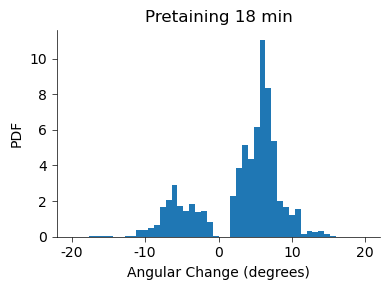

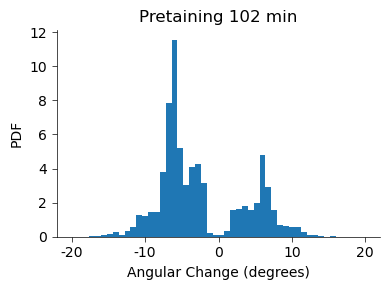

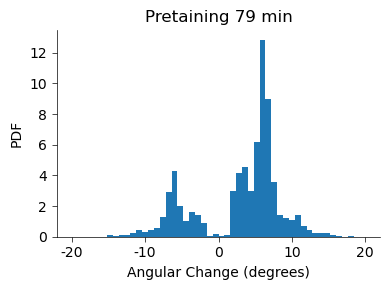

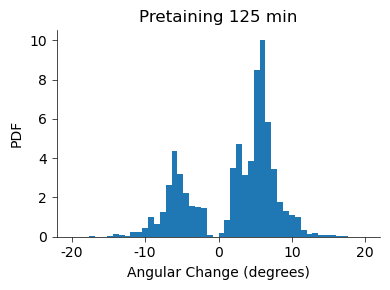

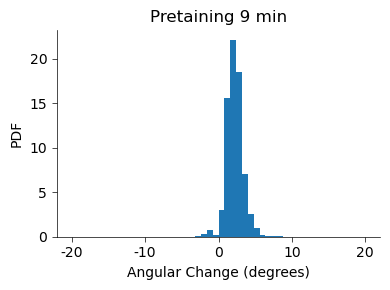

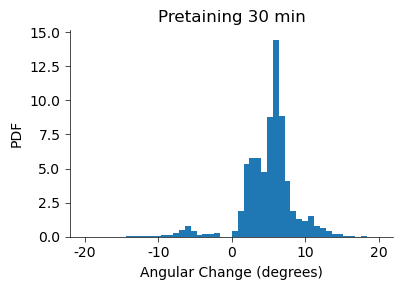

In [5]:
def plot_angular_change(path, save_dir):
    res = import16chFlt(path)
    angle = res['behav_orient']
    dangle = angle[1:] - angle[:-1]
    dangle[dangle > np.pi] -= 2 * np.pi
    dangle[dangle < -np.pi] += 2 * np.pi
    
    idx = np.where(
        (dangle <= -1e-3) | (dangle >= 1e-3)
    )[0]
    fig = plt.figure(figsize=(4, 3))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    ax.hist(dangle[idx], bins=50, range=(-np.pi/9, np.pi/9), density=True)
    ax.set_title(f"Pretaining {int(res['behav_time'][-1]/60)} min")
    ax.set_xticks(np.linspace(-np.pi/9, np.pi/9, 5), np.linspace(-20, 20, 5).astype(np.int64))
    ax.set_ylabel("PDF")
    ax.set_xlabel("Angular Change (degrees)")
    plt.tight_layout()
    plt.savefig(save_dir+".png", dpi=600)
    plt.savefig(save_dir+".svg", dpi=600)
    plt.show()
    del fig, ax
    del res

AngularChangePath = join(loc, "Angular Changes")
os.makedirs(AngularChangePath, exist_ok=True)

for fid, pt in zip(fish_ids, paths):
    save_dir = join(AngularChangePath, f"Distribution of Angular Changes [{fid}]")
    try:
        plot_angular_change(pt, save_dir)
    except Exception as e:
        print(f"Failed to process {pt}: {e}")

# Angular Change vs Swim Signals.

(array([    2908, 28564172,     8620], dtype=int64), array([-1.5, -0.5,  0.5,  1.5]))


KeyError: 'be'

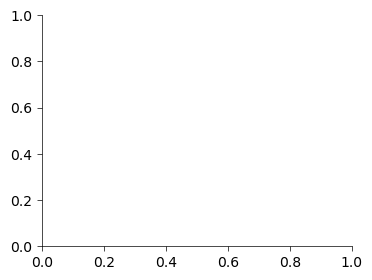

In [4]:
def align_signal_with_angular(path):
    res = import16chFlt(path)
    angle = res['behav_orient']
    dangle = np.append(np.diff(angle), 0)
    dangle[dangle > np.pi] -= 2 * np.pi
    dangle[dangle < -np.pi] += 2 * np.pi
    
    dangle_sign = np.where(dangle >= 0, 1, -1)
    dangle_sign[(dangle <= 1e-3)&(dangle >= -1e-3)] = 0
    print(np.histogram(dangle_sign, range=(-1.5, 1.5), bins=3))
    
    ch0 = res['fltCh0']
    ch1 = res['fltCh1']
    kernel = np.concatenate([
        np.ones(1200), np.linspace(1, 0, 1200)
    ])
    power_diff = np.convolve(ch0, kernel, mode='same') - np.convolve(ch1, kernel, mode='same')
    
    fig = plt.figure(figsize=(4, 3))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    ax.plot(res['behav_time'], res['be'])
    plt.show()

ps = r"D:\EnData\Open Field\10218\res.16chFlt"
power_diff = align_signal_with_angular(ps)

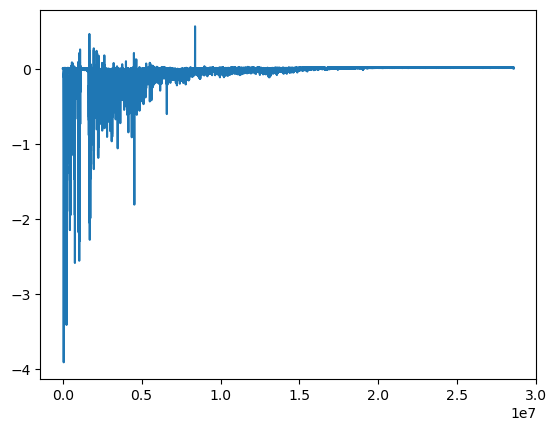

In [11]:
plt.plot(power_diff)

# Trajectory

In [6]:
path = r"D:\EnData\Light-sheet\10220\pretaining\res.16chFlt"
res, xpos, ypos = process(path)

# ================================================================
path2 = r"D:\EnData\Light-sheet\10220\S2\res.16chFlt"
res2, xpos2, ypos2 = process(path2)

fish = 10220

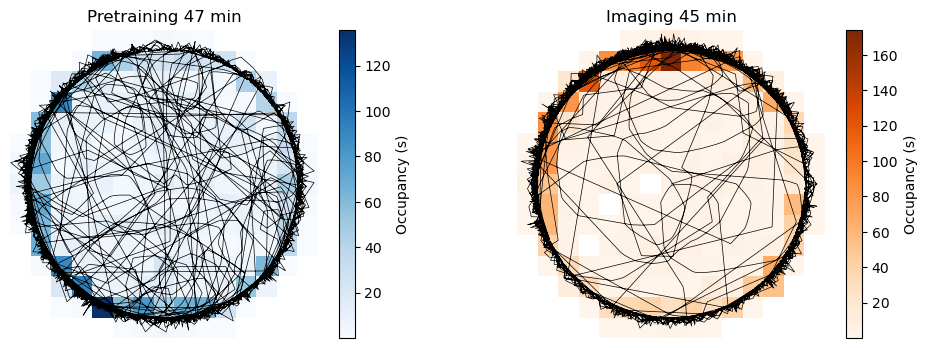

In [20]:
# ratemap
pretrain_ratemap = np.histogram2d(ypos, xpos, bins=15, range=[[35,65], [35,65]])[0]
pretrain_ratemap[pretrain_ratemap < 1e-2] = np.nan
imaging_ratemap = np.histogram2d(ypos2, xpos2, bins=15, range=[[35,65], [35,65]])[0]
imaging_ratemap[imaging_ratemap < 1e-2] = np.nan

fig, axes = plt.subplots(figsize=(12, 4), ncols=2, nrows=1)
ax0 = Clear_Axes(axes[0])
im0 = ax0.imshow(pretrain_ratemap/6000, origin='lower', extent=[35,65,35,65], cmap=sns.color_palette("Blues", as_cmap=True))
cbar0 = fig.colorbar(im0, ax=ax0)
cbar0.set_label("Occupancy (s)")
ax0.plot(xpos, ypos, linewidth=0.5, color='k')
ax0.set_aspect("equal")
ax0.set_title(f"Pretraining {int(res['behav_time'][-1] / 60)} min")

ax1 = Clear_Axes(axes[1])
im1 = ax1.imshow(imaging_ratemap/6000, origin='lower', extent=[35,65,35,65], cmap=sns.color_palette("Oranges", as_cmap=True))
ax1.plot(xpos2, ypos2, linewidth=0.5, color='k')
ax1.set_aspect("equal")
cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label("Occupancy (s)")
ax1.set_title("Imaging 45 min")
plt.savefig(join(loc, f"Trajectory {fish}.png"))
plt.savefig(join(loc, f"Trajectory {fish}.svg"))
plt.show()

# Turning

In [7]:
angle = res['behav_orient']
dangle = angle[1:] - angle[:-1]
dangle[dangle > np.pi] -= 2 * np.pi
dangle[dangle < -np.pi] += 2 * np.pi

angle2 = res2['behav_orient']
dangle2 = angle2[1:] - angle2[:-1]
dangle2[dangle2 > np.pi] -= 2 * np.pi
dangle2[dangle2 < -np.pi] += 2 * np.pi

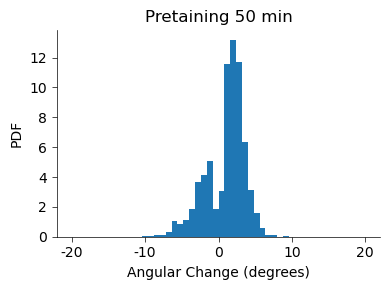

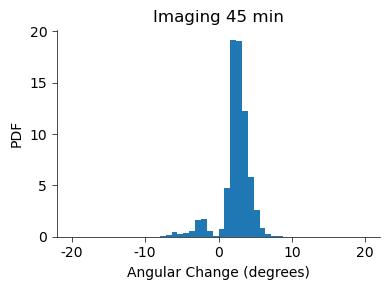

In [8]:
idx = np.where(
    (dangle <= -1e-3) | (dangle >= 1e-3)
)[0]
fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax.hist(dangle[idx], bins=50, range=(-np.pi/9, np.pi/9), density=True)
ax.set_title("Pretaining 50 min")
ax.set_xticks(np.linspace(-np.pi/9, np.pi/9, 5), np.linspace(-20, 20, 5).astype(np.int64))
ax.set_ylabel("PDF")
ax.set_xlabel("Angular Change (degrees)")
plt.tight_layout()
plt.savefig(join(loc, f"Distribution of Angular Changes [Pretraining, {fish}].png"), dpi=600)
plt.savefig(join(loc, f"Distribution of Angular Changes [Pretraining, {fish}].svg"), dpi=600)
plt.show()


idx = np.where(
    (dangle2 <= -1e-3) | (dangle2 >= 1e-3)
)[0]

fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax.hist(dangle2[idx], bins=50, range=(-np.pi/9, np.pi/9), density=True)
ax.set_title("Imaging 45 min")
ax.set_xticks(np.linspace(-np.pi/9, np.pi/9, 5), np.linspace(-20, 20, 5).astype(np.int64))
ax.set_xlabel("Angular Change (degrees)")
ax.set_ylabel("PDF")
plt.tight_layout()
plt.savefig(join(loc, f"Distribution of Angular Changes [Imaging, {fish}].png"), dpi=600)
plt.savefig(join(loc, f"Distribution of Angular Changes [Imaging, {fish}].svg"), dpi=600)
plt.show()

# Heading Changes

In [61]:
smooth_x, smooth_y = np.cos(angle), np.sin(angle)
smooth_x2, smooth_y2 = np.cos(angle2), np.sin(angle2)
smooth_x = np.convolve(smooth_x, np.ones(200)/200, mode='same')
smooth_y = np.convolve(smooth_y, np.ones(200)/200, mode='same')
smooth_x2 = np.convolve(smooth_x2, np.ones(200)/200, mode='same')
smooth_y2 = np.convolve(smooth_y2, np.ones(200)/200, mode='same')
smooth_angle = np.arctan2(smooth_y, smooth_x)
smooth_angle2 = np.arctan2(smooth_y2, smooth_x2)

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(6, 4))
ax0 = Clear_Axes(axes[0], close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax1 = Clear_Axes(axes[1], close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax0.set_xlabel("Time (s)")
ax0.set_title("Pretraining 50 min")
ax0.plot(res['behav_time'], smooth_angle)
ax1.plot(res2['behav_time'], smooth_angle2)
ax1.set_xlabel("Time (s)")
ax1.set_title("Imaging 45 min")

Text(0.5, 1.0, 'Imaging 45 min')

Error in callback <function _draw_all_if_interactive at 0x0000020A0D79EA70> (for post_execute), with arguments args (),kwargs {}:


MemoryError: Unable to allocate 262. MiB for an array with shape (2, 17170700) and data type float64

MemoryError: Unable to allocate 247. MiB for an array with shape (2, 16193300) and data type float64

<Figure size 600x400 with 2 Axes>

# Angular Speed vs. Swim Power

In [4]:
angular_dir = join(loc, "Angular Velocity")
mkdir(angular_dir)

def angular_velocity(i):
    res = import16chFlt(f_op['Ephys path'][i])
    t = res['behav_time']
    hd = res['behav_orient']
    dhd = np.diff(hd)
    dhd[dhd > np.pi] = 2 * np.pi - dhd[dhd > np.pi]
    dhd[dhd < -np.pi] = -2 * np.pi - dhd[dhd < -np.pi]
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 6))
    idx = np.where(np.abs(dhd) > 1e-8)[0]
    axes[0].plot(t[:-1][idx], hd[:-1][idx], color='k', linewidth=0.5, label='Head Direction')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Head Direction\n(radians)')
    axes[0].set_title(f'Head Direction and Angular Velocity - Fish {f_op["ID"][i]}')
    axt = axes[0].twinx()
    axt.set_ylabel('Angular Velocity\n(radians/frame)', color='r')
    axt.plot(t[:-1][idx], dhd[idx], color='r', linewidth=0.5)
    axt.set_ylim(-np.pi/9, np.pi/9)
    axt.spines['right'].set_color('r')
    axes[1].hist(np.rad2deg(dhd[idx]), bins=40, range=(-20, 20), density=True)
    axes[1].set_title(f'Angular Velocity - Fish {f_op["ID"][i]}')
    axes[1].set_xlabel('Angular Velocity\n(degrees/frame)')
    axes[1].set_ylabel('PDF')
    plt.tight_layout()
    plt.savefig(join(angular_dir, f'{f_op["ID"][i]}.png'))
    plt.savefig(join(angular_dir, f'{f_op["ID"][i]}.svg'))
    plt.close()
    
for i in tqdm(range(len(f_op))):
    angular_velocity(i)

        D:\Yao Shuyang\En Lab\Results\5004 - Open Field 2D\Angular Velocity is already existed!


100%|██████████| 6/6 [00:33<00:00,  5.63s/it]


7.42023439021456e-06 0.0002929433614991465
-0.003200181797209393


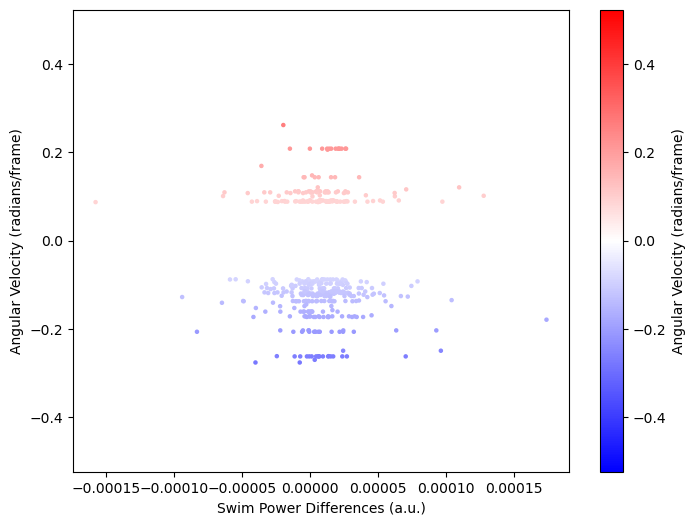

In [14]:
def turn_vs_swim(i):
    res = import16chFlt(f_op['Ephys path'][i])
    idx = np.where(res['behav_time'] > 6)[0]
    for k in res.keys():
        res[k] = res[k][idx]
        
    hd = res['behav_orient']
    dhd = np.diff(hd)
    dhd[dhd > np.pi] = 2 * np.pi - dhd[dhd > np.pi]
    dhd[dhd < -np.pi] = -2 * np.pi - dhd[dhd < -np.pi]
    
    t = res['behav_time']
    turn_moment = np.where(np.abs(dhd) > np.deg2rad(10))[0]
    ch0 = res['fltCh0']
    ch1 = res['fltCh1']
    print(np.min(ch0), np.max(ch0))
    
    idx = np.where(np.abs(dhd) > np.deg2rad(5))[0]
    fig = plt.figure(figsize=(8, 6))
    ax = plt.axes()
    sc = ax.scatter(
        ch0[idx] - ch1[idx],
        dhd[idx],
        c=dhd[idx], 
        cmap='bwr', 
        s=5, 
        vmin=-np.deg2rad(30), 
        vmax=np.deg2rad(30)
    )
    plt.colorbar(sc, label='Angular Velocity (radians/frame)')
    ax.set_xlabel('Swim Power Differences (a.u.)')
    ax.set_ylabel('Angular Velocity (radians/frame)')
    ax.set_ylim(-np.deg2rad(30), np.deg2rad(30))
    print(np.corrcoef(ch0[idx] - ch1[idx], dhd[idx])[0, 1])
    plt.show()
    
turn_vs_swim(0)